In [7]:
import numpy as np
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt


In [8]:
import idna #implementacion de tecnicas de codificacion de strings (codificacion y decodificacion de caracterers unicode)

# def utf8_to_punycode(text: str) -> str:
#     """Encodes a UTF-8 string to its Punycode representation."""
#     return idna.encode(text).decode('ascii')

def punyencode(text: str) -> str:
    """Encodes a UTF-8 string to its Punycode representation, handling spaces by encoding each word separately."""
    
    return " ".join([idna.encode(word).decode('ascii') for word in text.split()])
    
def punydecode(punycode: str) -> str:
    """Decodes a Punycode string back to UTF-8."""
    #return idna.decode(punycode)
    return " ".join([idna.decode(word) for word in punycode.split()])

def process_name(name):
    name = name.lower()
    for n in name.split():
        if len(n) < 2:
            return ''
    try:
        return punyencode(name)
    except:
        #print(f'Cant convert {name}')
        return ''

dataset = open("city_names_full.txt", 'r', encoding='utf-8').read().split('\n')
with open('city_names_puny.txt', 'w', encoding='utf-8') as f:
    for n in dataset:
        name = process_name(n)
        if name != '':
            f.write(name + '\n')
dataset = open('city_names_puny.txt', 'r', encoding='utf-8').read().split('\n')
puny = [x for x in dataset if 'xn--' in x] #filtrar todos los que tienen caracteres raros
nopuny = [x for x in dataset if 'xn--' not in x]
np.random.seed(42)
dataset = [x.item() for x in np.random.choice(nopuny, 100000, replace=False)]

In [9]:
#construyendo dataset para makemore con MLPS

In [10]:
print(len(dataset))
charset = ['*'] + sorted(list(set([y for x in dataset for y in x])))
ctoi = {c:i for i, c in enumerate(charset)}
itoc = {i:c for i, c in enumerate(charset)}
charset_size = len(charset)


100000


In [11]:
context_size = 3
X, Y = [], []

for d in dataset[:1]:
    print(d)
    example = list(d) + ['*']
    context = [0] * context_size
    for c in example:
        print(''.join([itoc[x] for x in context])+ '---> + c')
        X.append(context)
        Y.append(ctoi[c])
        context = context[1:] + [ctoi[c]]

kotamangalam
***---> + c
**k---> + c
*ko---> + c
kot---> + c
ota---> + c
tam---> + c
ama---> + c
man---> + c
ang---> + c
nga---> + c
gal---> + c
ala---> + c
lam---> + c


In [12]:
X, Y

([[0, 0, 0],
  [0, 0, 24],
  [0, 24, 28],
  [24, 28, 33],
  [28, 33, 14],
  [33, 14, 26],
  [14, 26, 14],
  [26, 14, 27],
  [14, 27, 20],
  [27, 20, 14],
  [20, 14, 25],
  [14, 25, 14],
  [25, 14, 26]],
 [24, 28, 33, 14, 26, 14, 27, 20, 14, 25, 14, 26, 0])

In [13]:
#Red neuronal

In [14]:
g = torch.Generator().manual_seed(42)
emb_size = 2
C = torch.randn(charset_size, emb_size, generator=g)#genera una matriz de 40*2
C

tensor([[ 1.9269,  1.4873],
        [ 0.9007, -2.1055],
        [ 0.6784, -1.2345],
        [-0.0431, -1.6047],
        [-0.7521,  1.6487],
        [-0.3925, -1.4036],
        [-0.7279, -0.5594],
        [-0.7688,  0.7624],
        [ 1.6423, -0.1596],
        [-0.4974,  0.4396],
        [-0.7581,  1.0783],
        [ 0.8008,  1.6806],
        [ 1.2791,  1.2964],
        [ 0.6105,  1.3347],
        [-0.2316,  0.0418],
        [-0.2516,  0.8599],
        [-1.3847, -0.8712],
        [-0.2234,  1.7174],
        [ 0.3189, -0.4245],
        [ 0.3057, -0.7746],
        [-1.5576,  0.9956],
        [-0.8798, -0.6011],
        [-1.2742,  2.1228],
        [-1.2347, -0.4879],
        [-0.9138, -0.6581],
        [ 0.0780,  0.5258],
        [-0.4880,  1.1914],
        [-0.8140, -0.7360],
        [-1.4032,  0.0360],
        [-0.0635,  0.6756],
        [-0.0978,  1.8446],
        [-1.1845,  1.3835],
        [ 1.4451,  0.8564],
        [ 2.2181,  0.5232],
        [ 0.3466, -0.1973],
        [-1.0546,  1

In [15]:
#onehot es un vector que dependiendo de el numero que se ingrese va a mostrar 1 en el indice del caracter que se esta codeando (?)
#F.one_hot(torch.tensor(0), num_classes = charset_size).float()
F.one_hot(torch.tensor(0), num_classes = charset_size).float() @ C

tensor([1.9269, 1.4873])

In [16]:
F.one_hot(torch.tensor(X), num_classes = charset_size).float() @ C #devuelve una matriz con el embedding de cada uno de los char de X(pesos)

tensor([[[ 1.9269,  1.4873],
         [ 1.9269,  1.4873],
         [ 1.9269,  1.4873]],

        [[ 1.9269,  1.4873],
         [ 1.9269,  1.4873],
         [-0.9138, -0.6581]],

        [[ 1.9269,  1.4873],
         [-0.9138, -0.6581],
         [-1.4032,  0.0360]],

        [[-0.9138, -0.6581],
         [-1.4032,  0.0360],
         [ 2.2181,  0.5232]],

        [[-1.4032,  0.0360],
         [ 2.2181,  0.5232],
         [-0.2316,  0.0418]],

        [[ 2.2181,  0.5232],
         [-0.2316,  0.0418],
         [-0.4880,  1.1914]],

        [[-0.2316,  0.0418],
         [-0.4880,  1.1914],
         [-0.2316,  0.0418]],

        [[-0.4880,  1.1914],
         [-0.2316,  0.0418],
         [-0.8140, -0.7360]],

        [[-0.2316,  0.0418],
         [-0.8140, -0.7360],
         [-1.5576,  0.9956]],

        [[-0.8140, -0.7360],
         [-1.5576,  0.9956],
         [-0.2316,  0.0418]],

        [[-1.5576,  0.9956],
         [-0.2316,  0.0418],
         [ 0.0780,  0.5258]],

        [[-0.2316,  0

In [17]:
# (13, 3 ,40) @ (40, 2) --> (13, 3, 2)

In [18]:
C[[X]] #esto es el equivalente a la multiplicacion de matrices que devuelve la matriz de embeddings arriba

# Importante!
# • El tamaño contexto de nuestro modelo (cuántos caracteres se utilizan para predecir la distribución de probabilidad del siguiente) determina muchas cosas y es conveniente
# tener claro cual es este número. En nuestro ejemplo, el tamaño del contexto es 3. Es decir, utilizamos 3 caracteres para predecir el siguiente.
# • La matriz C puede interpretarse como la primer capa de perceptronoes.
# • C tiene 2 perceptrones de 40 entradas, es decir tiene 40 entradas y 2 salidas, lo que permite codificar 1 caracter en 2 dimensiones
# • Nuestro modelo no recibe como entrada un one hot de 40 dimensiones, recibe el índice de 3 caracteres.
# • Codificar 3 caracteres requiere que multiplicar (3, 40)@(40, 2) (3, 2) es decir, primero tenemos que calcular el one hot de los 3 caracteres y despues
# multiplicar los one hot por C.
# • Durante el entrenamiento vamos a querer mandarle "batches" de 3 caracteres. Es decir, vamos a queresr enviar varios grupos de 3 caracteres. Si el tamaño del grupo es
# de 13, como vimos en el ejemplo, podemos interpretar que capa C esta recibiendo 13 grupos de 3 caracteres encodeados en one hot cuya dimensión seria (13,
# 3, 40) y lo va a multiplicar por (40, 2), es decir (13, 3, 40)@(40, 2) (13, 3, 2). La salida se puede interpretar como 13 grupos de 3 caracteres encodeados en 2
# dimensiones (las dimensiones del embedding).
# • Se puede lograr el mismo efecto indexando C mediante el uso las ténicas avanzadas de indexing de PyTorch, en lugar de hacer operaciones con matrices (guiño, guiño).
# • En general las dimensiones del modelo van a ser de
# o Entrada: (batch_size, context_size, (charsetLSize)J0, charset_size será necesario si usamos one hot encondig, se puede obviar si usamos indexing.
# o Primer capa (Matriz de embeddings): (charset_size, es decir, una red de emb_size perceptrones (emb_size salidas), cada uno con charset_size
# entradas.
# o Salida: (batch_size, context_size,emb_size)
# o (batch_size, context_size, (charset_size)) @ (charset_size, emb_size) (batch_size, context_size,emb_size)
# • Es necesario tener presente el tamaño de la salida por que de eso depende el tamaño de la entrada de la siquiente capa.

C:\Users\TheCague\AppData\Local\Temp\ipykernel_10284\934146368.py:1: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:353.)
  C[[X]] #esto es el equivalente a la multiplicacion de matrices que devuelve la matriz de embeddings arriba


tensor([[[ 1.9269,  1.4873],
         [ 1.9269,  1.4873],
         [ 1.9269,  1.4873]],

        [[ 1.9269,  1.4873],
         [ 1.9269,  1.4873],
         [-0.9138, -0.6581]],

        [[ 1.9269,  1.4873],
         [-0.9138, -0.6581],
         [-1.4032,  0.0360]],

        [[-0.9138, -0.6581],
         [-1.4032,  0.0360],
         [ 2.2181,  0.5232]],

        [[-1.4032,  0.0360],
         [ 2.2181,  0.5232],
         [-0.2316,  0.0418]],

        [[ 2.2181,  0.5232],
         [-0.2316,  0.0418],
         [-0.4880,  1.1914]],

        [[-0.2316,  0.0418],
         [-0.4880,  1.1914],
         [-0.2316,  0.0418]],

        [[-0.4880,  1.1914],
         [-0.2316,  0.0418],
         [-0.8140, -0.7360]],

        [[-0.2316,  0.0418],
         [-0.8140, -0.7360],
         [-1.5576,  0.9956]],

        [[-0.8140, -0.7360],
         [-1.5576,  0.9956],
         [-0.2316,  0.0418]],

        [[-1.5576,  0.9956],
         [-0.2316,  0.0418],
         [ 0.0780,  0.5258]],

        [[-0.2316,  0

In [19]:
#Capa oculta (capa de perceptrones con una funcion de activacion) (capa de neuronas)
emb = C[[X]] #embeddings del dataset (pesos)

C:\Users\TheCague\AppData\Local\Temp\ipykernel_10284\501557912.py:2: UserWarning: Using a non-tuple sequence for multidimensional indexing is deprecated and will be changed in pytorch 2.9; use x[tuple(seq)] instead of x[seq]. In pytorch 2.9 this will be interpreted as tensor index, x[torch.tensor(seq)], which will result either in an error or a different result (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\torch\csrc\autograd\python_variable_indexing.cpp:353.)
  emb = C[[X]] #embeddings del dataset (pesos)


In [20]:

#definicion de la capa oculta
n_hidden = 128 #128 neuronas, cada una con sus entradas y salidas
W1 = torch.randn(emb_size * context_size,  n_hidden) #el contexto esta enbebido en 2 dimensiones y son 3 caracteres en el contexto, cantidad de perceptrones
b1 = torch.randn(n_hidden) #bias

In [21]:

emb [0, 0], emb[0,1], emb[0,2]
#forward pass
F.tanh(emb[0].view(-1, 6) @ W1 + b1 )#salida de la capa C por la capa de perceptrones, aplicandole la funcion de activacion(tanh)


tensor([[-0.9691,  0.9185,  1.0000, -0.9657, -0.9769, -0.2690, -0.9907, -0.9802,
          0.9612,  1.0000,  0.7341,  0.9988,  1.0000, -0.9385, -0.7218, -0.9999,
          0.9076, -0.6039, -0.9999, -0.9100, -1.0000,  1.0000,  0.9886, -0.9999,
         -0.9996, -0.9909, -1.0000,  0.9876, -0.9999, -0.9902, -0.6138, -0.0317,
         -0.5201, -0.9980,  0.9972,  0.5767,  0.9971,  0.4269,  0.9998, -1.0000,
          0.9980, -0.9988, -1.0000,  1.0000, -0.1794, -0.9999, -0.4547,  1.0000,
          1.0000,  1.0000,  0.6808, -0.9810,  0.8330,  0.9166, -0.9905,  0.0571,
         -0.3544, -0.9997,  0.9984, -0.9582,  0.1701, -1.0000,  0.5173, -0.9916,
          0.9992,  0.1550,  0.6518, -0.8142,  1.0000, -0.6597, -0.6785,  0.9921,
          0.9964, -0.8139,  0.9997,  1.0000,  1.0000,  0.9253,  0.9995, -0.9999,
          0.9993,  0.5017,  0.9986, -0.9969,  0.9975,  1.0000,  0.9106, -1.0000,
         -0.9665, -0.9999,  0.5269, -0.8332, -0.7432,  0.1985,  1.0000,  0.9987,
         -0.9986, -0.9980, -

In [22]:
# (1,6) @ (6, 128) -> si le se suma 'algo de 128' se conoce como broadcasting rules
# la suma de una listas de listas y una lista, siempre y cuando:
# compartan las mismas dimensiones, o que una de las dimensiones sea 1 o una de las dimensiones no existe
# cada tensor tiene por lo menos una dimension


In [23]:
torch.tensor([[1,2,3,4], [2,3,4,5]]) + torch.tensor([1,2,3,4])
torch.tensor([[1,2,3,4], [2,3,4,5]]).shape, torch.tensor([1,2,3,4]).shape
# 2, 4(en este caso los 4 tenian que ser iguales)
# X, 4

(torch.Size([2, 4]), torch.Size([4]))

In [24]:
#capa output

W2 = torch.randn(n_hidden, charset_size)
b2 = torch.randn(charset_size)


In [25]:
act = F.tanh(emb[0].view(-1, 6) @ W1 + b1 )

In [26]:
#(13,128) @ (128, 40) --> (13, 40)
logits = act @ W2 + b2
counts = logits.exp()
probs = counts/counts.sum(axis=1, keepdims = True)

#e ** log(x)

In [27]:
probs

tensor([[1.1929e-07, 3.0519e-06, 3.3750e-13, 5.4118e-13, 4.2322e-09, 6.1422e-10,
         1.6610e-04, 1.0762e-03, 1.4699e-05, 8.0534e-09, 2.1378e-12, 2.1338e-11,
         7.4527e-19, 1.5441e-10, 1.3621e-10, 7.6524e-10, 3.6622e-12, 7.3039e-01,
         3.2799e-09, 5.5314e-15, 8.1959e-17, 9.8527e-15, 4.7787e-06, 5.3470e-10,
         1.6558e-06, 3.9379e-09, 9.6830e-17, 5.7275e-11, 2.7223e-02, 7.8011e-06,
         1.9505e-01, 8.8015e-06, 4.3832e-05, 2.9974e-07, 4.5557e-02, 4.4603e-04,
         9.2008e-11, 1.9117e-17, 3.3511e-07, 4.3429e-07]])

In [ ]:
#pasando a limpio
context_size = 3  # El tamaño del contexto o cuantos caracteres vamos a usar para predecir el siguiente
X, Y = [], []

for d in dataset[:1]:
    #print(d)
    example = list(d) + ['*']
    context = [0] * context_size
    for c in example:
        #print(''.join([itoc[x] for x in context]) + ' --> ' + c)
        X.append(context)
        Y.append(ctoi[c])
        context = context[1:] + [ctoi[c]]
X = torch.tensor(X)
Y = torch.tensor(Y)



In [61]:
import idna

# def utf8_to_punycode(text: str) -> str:
#     """Encodes a UTF-8 string to its Punycode representation."""
#     return idna.encode(text).decode('ascii')

def punyencode(text: str) -> str:
    """Encodes a UTF-8 string to its Punycode representation, handling spaces by encoding each word separately."""
    
    return " ".join([idna.encode(word).decode('ascii') for word in text.split()])
    
def punydecode(punycode: str) -> str:
    """Decodes a Punycode string back to UTF-8."""
    #return idna.decode(punycode)
    return " ".join([idna.decode(word) for word in punycode.split()])

def process_name(name):
    name = name.lower()
    for n in name.split():
        if len(n) < 2:
            return ''
    try:
        return punyencode(name)
    except:
        #print(f'Cant convert {name}')
        return ''

dataset = open("city_names_full.txt", 'r', encoding='utf-8').read().split('\n')
with open('city_names_puny.txt', 'w') as f:
    for n in dataset:
        name = process_name(n)
        if name != '':
            f.write(name+'\n')
dataset = open("city_names_puny.txt", 'r', encoding='utf-8').read().split('\n')
puny = [x for x in dataset if 'xn--' in x]
nopuny = [x for x in dataset if 'xn--' not in x]
np.random.seed(42)
dataset = [x.item() for x in np.random.choice(nopuny, 100000,replace=False)]

In [63]:
W1.nelement(), 6*128

(768, 768)

In [67]:
model.count_parameters()

6136

In [65]:
logits = model(X)
logits

tensor([[-1.1633e+01, -1.0063e+01,  1.1393e+01,  6.5970e+00,  1.4622e+01,
         -6.4226e+00,  1.2090e+01, -2.1454e+00,  4.0184e+00,  1.9550e+00,
          1.0228e+00,  2.8076e+00, -1.7364e+01,  1.3314e+01,  2.2958e+00,
         -1.3530e+01, -1.0533e+01,  3.1635e+00, -1.5997e+00,  3.0007e+00,
         -4.5677e+00, -3.9613e+00, -1.2003e+00, -1.2259e+01, -1.3796e+00,
         -7.4258e+00, -5.1031e+00,  2.1897e+01,  1.0156e+01,  1.9434e-01,
          6.4875e+00,  1.8054e+00,  5.9498e+00, -2.0549e+01, -7.6935e+00,
          8.4564e+00,  2.9527e+00,  1.5392e+01,  8.2472e+00,  2.7663e+00],
        [-8.9235e+00, -2.6640e+01,  6.7582e+00,  6.5792e+00, -1.0319e+00,
          5.2710e-01, -6.1049e+00, -2.0140e+01,  6.4002e+00,  6.7794e+00,
          1.5809e+01, -4.3605e-01, -2.7213e+00,  5.1579e+00,  1.0287e+01,
         -1.0783e+00, -1.2949e+01,  3.2445e+01, -5.4687e-01,  5.1931e+00,
          6.7612e+00,  8.5618e+00, -8.6390e+00, -1.0001e+00, -8.0503e+00,
         -2.7664e+00, -1.2017e+01,  1

In [68]:
nll(model(X), Y)

tensor(22.3948, grad_fn=<NegBackward0>)

In [70]:
model(X[0]).argmax()

tensor(24)

In [71]:
itoc[24]

'k'

In [89]:
class Model:
    def __init__(self, charset_size, context_size, emb_size, hidden_size, g=torch.Generator().manual_seed(42)):
        self.charset_size = charset_size
        self.context_size = context_size
        self.emb_size = emb_size
        self.hidden_size = hidden_size
        self.C = torch.randn(self.charset_size, self.emb_size, generator=g)
        self.W1 = torch.randn(self.emb_size*self.context_size, self.hidden_size, generator=g)
        self.b1 = torch.randn(self.hidden_size, generator=g)
        self.W2 = torch.randn(self.hidden_size, self.charset_size, generator=g)
        self.b2 = torch.randn(self.charset_size, generator=g)
        self.parameters = [self.C, self.W1, self.b1, self.W2, self.b2]
        for p in self.parameters:
            p.requires_grad = True
    
    def __call__(self, x):
        emb = self.C[x]
        act = torch.tanh(emb.view(-1, self.emb_size*self.context_size) @ self.W1 + self.b1)
        logits = act @ self.W2 + self.b2
        return logits

    def count_parameters(self):
        return sum([p.nelement() for p in self.parameters])
    
    def sample(self, nsamples, g=torch.Generator().manual_seed(42)):
        samples = []
        for n in range(nsamples):
            context = [0] * context_size
            out = []
            while True:
                logits = self(torch.tensor(context))
                # counts = logits.exp()
                # probs = counts / counts. sum(1, keepdims=True)
                probs = F.softmax(logits, dim=1)
                idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
                context = context[1:] + [idx]
                out.append(itoc[idx])
                if idx == 0:
                    samples.append(''.join(out[:-1]))
                    break
        return samples


def nll(logits, Y): 
    return F.cross_entropy(logits,  Y)
    #esto es reemplazado de ahora en adelante por F.cross_Entropy(hace lo mismo)
    # counts = logits.exp()
    # probs = counts / counts. sum(1, keepdims=True)
    # return -(probs[torch.arange(len(Y)), Y]).log().mean()

In [ ]:
#F.cross_Entropy y F.softmax


logits = torch.tensor([-5., -2., 1., 5])
counts = logits.exp()
probs = counts/counts.sum()
probs.sum()

tensor(1.)

In [75]:
#F.cross_entropy(torch.tensor([-5., -2., 1., 5]), torch.tensor([0,2,3,4]))

In [ ]:
logits = model(X)
F.cross_entropy(logits, Y), nll(logits, Y)
#counts = logits.exp()
#probs = counts/counts.sum(1, keepdims=True) 
F.softmax(logits, dim=1)[0], probs[0] #esto es lo mismo que hacer las dos lineas de arriba pero funciona mejor

tensor([[1.4004e-13, 6.3350e-09, 1.6175e-11, 1.2886e-08, 2.0109e-03, 3.0500e-10,
         6.0498e-04, 3.3676e-12, 7.9321e-07, 1.4064e-12, 2.5963e-10, 2.0689e-10,
         1.7602e-13, 5.9660e-07, 3.1834e-11, 1.9537e-04, 3.1882e-07, 1.9235e-12,
         1.1714e-05, 1.5889e-09, 2.8731e-08, 8.5239e-09, 3.1139e-09, 5.2899e-14,
         9.9244e-01, 5.7896e-13, 9.4575e-14, 1.6602e-03, 2.5975e-03, 4.8356e-16,
         2.0493e-10, 9.7135e-10, 3.3524e-04, 1.6242e-12, 4.3809e-12, 1.2942e-10,
         6.9670e-05, 1.5852e-08, 1.2368e-11, 7.6261e-05],
        [3.7754e-13, 6.6535e-15, 6.8985e-11, 9.0301e-14, 2.2324e-07, 1.3256e-07,
         1.9635e-06, 2.9909e-15, 5.5686e-05, 1.0485e-15, 1.4692e-05, 1.7465e-06,
         1.7571e-22, 1.4908e-07, 4.0171e-16, 1.4458e-11, 6.8435e-17, 1.5148e-11,
         2.1178e-03, 7.0884e-10, 4.0110e-06, 8.6677e-16, 2.2032e-14, 3.0850e-13,
         1.0224e-10, 3.3500e-09, 4.5668e-12, 3.2488e-04, 9.9554e-01, 5.2377e-12,
         2.9731e-11, 1.0080e-12, 1.9707e-04, 1.5866

In [93]:
model.sample(10)

['ndx',
 'nofm5m',
 'ndxmndf',
 'ndxmxmsxnoc',
 'ndxmndfmxmsxndf',
 'ndf',
 'ndf',
 'ndxmsxndf',
 'ndf',
 'ndxmxdsndf']

In [99]:
#Vuelta a pasar en limpio

context_size = 3  # El tamaño del contexto o cuantos caracteres vamos a usar para predecir el siguiente
X, Y = [], []

for d in dataset:
    #print(d)
    example = list(d) + ['*']
    context = [0] * context_size
    for c in example:
        #print(''.join([itoc[x] for x in context]) + ' --> ' + c)
        X.append(context)
        Y.append(ctoi[c])
        context = context[1:] + [ctoi[c]]
X = torch.tensor(X)
Y = torch.tensor(Y)
len(X), len(Y)

(1046932, 1046932)

In [95]:
class Model:
    def __init__(self, charset_size, context_size, emb_size, hidden_size, g=torch.Generator().manual_seed(42)):
        self.charset_size = charset_size
        self.context_size = context_size
        self.emb_size = emb_size
        self.hidden_size = hidden_size
        self.C = torch.randn(self.charset_size, self.emb_size, generator=g)
        self.W1 = torch.randn(self.emb_size*self.context_size, self.hidden_size, generator=g)
        self.b1 = torch.randn(self.hidden_size, generator=g)
        self.W2 = torch.randn(self.hidden_size, self.charset_size, generator=g)
        self.b2 = torch.randn(self.charset_size, generator=g)
        self.parameters = [self.C, self.W1, self.b1, self.W2, self.b2]
        for p in self.parameters:
            p.requires_grad = True
    
    def __call__(self, x):
        emb = self.C[x]
        act = torch.tanh(emb.view(-1, self.emb_size*self.context_size) @ self.W1 + self.b1)
        logits = act @ self.W2 + self.b2
        return logits

    def count_parameters(self):
        return sum([p.nelement() for p in self.parameters])
    
    def sample(self, nsamples, g=torch.Generator().manual_seed(42)):
        samples = []
        for n in range(nsamples):
            context = [0] * context_size
            out = []
            while True:
                logits = self(torch.tensor(context))
                # counts = logits.exp()
                # probs = counts / counts. sum(1, keepdims=True)
                probs = F.softmax(logits, dim=1)
                idx = torch.multinomial(probs, num_samples=1, replacement=True, generator=g).item()
                context = context[1:] + [idx]
                out.append(itoc[idx])
                if idx == 0:
                    samples.append(''.join(out[:-1]))
                    break
        return samples


def nll(logits, Y): 
    return F.cross_entropy(logits,  Y)
    #esto es reemplazado de ahora en adelante por F.cross_Entropy(hace lo mismo)
    # counts = logits.exp()
    # probs = counts / counts. sum(1, keepdims=True)
    # return -(probs[torch.arange(len(Y)), Y]).log().mean()

In [96]:
model = Model(charset_size,context_size, emb_size, n_hidden, torch.Generator().manual_seed(42))

In [101]:
lr = 0.1
steps = 100
for _ in range(steps):
    #1. Forwards pass
    logits = model(X)

    #2. Loss
    loss = nll(logits, Y)
    loss

    #3. zero grad
    for p in model.parameters:
        p.grad = None

    #4. backwards pass
    loss.backward()

    #5. update
    for p in model.parameters:
        p.data -= p.grad * lr
    print(loss.item())

16.046161651611328
15.54139232635498
15.076698303222656
14.644928932189941
14.241798400878906
13.863778114318848
13.507351875305176
13.168915748596191
12.845259666442871
12.533941268920898
12.233232498168945
11.941864967346191
11.659042358398438
11.384652137756348
11.119523048400879
10.865254402160645


KeyboardInterrupt: 

In [98]:
model.sample(20)

['kotamangalam',
 'kotamangalam',
 'kotamangalam',
 'kotamangalam',
 'kotamangalamn',
 'kotamangalam',
 'kotamangalam',
 'kotamangalam',
 'kotamangamangblsndam',
 'kotamangalam',
 'kotamangalam',
 'kotamangalam',
 'kotamangalam',
 'kota',
 'kotamangalam',
 'kotamangalam',
 'kotamangalam',
 'kotamangal',
 'kotamalam',
 'kotamangalam']

In [119]:
def build_dataset(dataset: list):
    X, Y  = [], []
    for d in dataset:
        example = list(d) + ['*']
        context = [0] * context_size
        for c in example:
            X.append(context)
            Y.append(ctoi[c])
            context = context[1:] + [ctoi[c]] 
    X = torch.tensor(X)
    Y = torch.tensor(Y)
    return X, Y

In [120]:
# build the dataset
context_size = 3
np.random.seed(42)
np.random.shuffle(dataset)
n1 = int(.8 * len(dataset))  # límite para el 80% del dataset
n2 = int(.9 * len(dataset))  # límite para el 90% del dataset
Xtr, Ytr = build_dataset(dataset[:n1])    # 80%
Xva, Yva = build_dataset(dataset[n1:n2])  # 10%
Xte, Yte = build_dataset(dataset[n2:])    # 10%

In [ ]:
#Entrenamiento por lotes

batch_size = 512
lr = 0.1
steps = 10000
losses = []
for i in range(steps):
    #1. Forwards pass
    idx = torch.randint(0, len(Xtr),(batch_size, ))
    logits = model(Xtr[idx])

    #2. Loss
    loss = nll(logits, Ytr[idx])
    losses.append(loss.item())

    #3. zero grad
    for p in model.parameters:
        p.grad = None

    #4. backwards pass
    loss.backward()

    #5. update
    for p in model.parameters:
        p.data -= p.grad * lr
        if i % 1000 == 0:
            lr -= 0.01
print(loss.item())


208799.859375


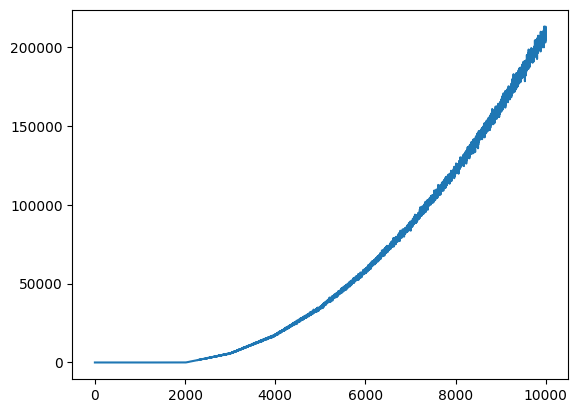

In [124]:
plt.plot(losses)

In [109]:
nll(model(Xva), Yva)

tensor(2.6550, grad_fn=<NllLossBackward0>)

In [110]:
model.sample(10)

['kumaddanda ally',
 'mollospia',
 'cludchann',
 'forp',
 'baseng glavleleggema',
 'turge',
 'sun',
 'zudtan',
 'caago',
 'colte']